In [37]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np
from numpy.ma.core import less_equal
from tqdm import tqdm
import matplotlib.pyplot as plt

In [38]:
# Create Model
m = gp.Model("Model_1")

In [39]:
# Time Based GMCNF parameters

# Gravitational acceleration [m/sˆ2]
g_0 = 9.80665

# Number of nodes i,j
nodes = 4

Connections = {0: [0,1] ,
               1: [0,1,2],
               2: [1,2,3],
               3: [2,3]}

# Time Steps 12 (days) #testing with +1 day
T = 12

# Advanced Time window
T_adv = list(range(T))
print(T_adv)
#in case multiple time windows are needed this can be added




# Velocity change [km/s]
#this model optimizes for IMLEO,
#  so it does not consider any velocity chage necessary for LEO-PAC (splashdown)
#However, since the model includes splash down, and we want only a single launch per day,
#We can add a Large (big M ) cost for PAC to LEO to ensure that the model does not use this arc
# unless it is really necessary

#Pacific Ocean, Low Earth Orbit, Lunar Lunar Orbit, Lunar Surface
# PAC, LEO, LLO, LS are 0, 1, 2, 3
delta_V = {0: {0: 0, 1: 1000}, # PAC to LEO is Big M high
            1: {0: 0, 1: 0, 2: 4.04},
              2: {1: 4.04, 2: 0, 3: 1.87},
                3: {2: 1.87, 3: 0}}

# Time of travel [days]
TOF = {0: {0: 1, 1: 1},
        1: {0: 1, 1: 1, 2: 3},
          2: {1: 3, 2: 1, 3: 1},
            3: {2: 1, 3: 1}}

# I, J = nodes, nodes
# For a general model, the arc routes must be manually defined, since you can only get to certain locations from certain arcs
routes = {i: [j for j in range(nodes) if abs(i - j) <= 1] for i in range(nodes)}

print(routes)

#WIll be a backup for later in case the routes does not work
def AllpossibleOutflowArcs(Connections, T_adv, connect = routes, TOF = TOF):
    possiblearc = []
    for t in T_adv:
        timepoint = []
        for i in Connections:
            for j in Connections[i]:
                if t+ TOF[i][j] in T_adv:
                    timepoint.append([i,j])
        possiblearc.append(timepoint)
    
    return possiblearc
test = AllpossibleOutflowArcs(Connections,T_adv,routes,TOF)
                
        
        


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
{0: [0, 1], 1: [0, 1, 2], 2: [1, 2, 3], 3: [2, 3]}


In [40]:
# VEHICLE DATA

"""
#Simplified test data
# Structure mass [kg]
s = np.array([40000, 15000, ])

# Specific impulses [s]
I_sp = np.array([421, 324])

# Payload Capacity [kg]
C = np.array([5000, 2500])

# Propellant Capacity [kg]
M = np.array([1200770, 400000])
"""




# Number of vehicle types
V = 6



Y = GRB.INTEGER
# Spacecrafts of same type


#Vehicles: [Saturn V stage 2, Saturn V stage 3, Command Module, Service Module, LM Descent Stage, LM ascent stage]


# Structure mass [kg]
s = np.array([38415, 12014, 4841, 6053, 2770, 1719])

# Specific impulses [s]
I_sp = np.array([421, 421, 0, 314, 311, 311])

# Payload Capacity [kg]
C = np.array([0, 0, 524, 60, 500, 250])

# Propellant Capacity [kg] 
M = np.array([452045, 107725, 0, 18413, 8804, 2358])

# Propellant mass fraction
#defined from rocket equation 1-e**(-deltav/Ispg0)

#actually the official function is e**(-deltav/Ispg0), but using the 1-e form allows use 
# to multiply the contents with the unchanging masses to include their input into the transformation linearly
#This varies with the delta v necessary for each arc, and the Isp of the vehicle used for that arc
#Will be used later
# list of dictionaries, 1 per node (of network) per vehicle type

def phi(i,j,v, dV = delta_V, I_sp = I_sp, g_0 = g_0):
    if I_sp[v] == 0:
        return 1
    else:
        return 1 - np.exp(-(1000*dV[i][j] / (I_sp[v] * g_0)))





In [ ]:
# COMMODITY Data and Demand/Supply

# Commodity variable types
X = [GRB.INTEGER, GRB.CONTINUOUS, GRB.CONTINUOUS, GRB.CONTINUOUS, GRB.CONTINUOUS]

PropIndex = 4 #Which commodity is the propellant? to apply single engine constraint

# Crew, consumables kg, equipment kg, samples kg, propellant kg
# PAYLOAD ASSUMPTIONS

# Consumption rates [kg/crew/day]
food_consumption = 1.0
water_consumption = 5.0
oxygen_consumption = 1.1
consumption = food_consumption + water_consumption + oxygen_consumption
#if the model works, this can be made more granular by separating the consumptions

# Crew mass [kg/crew]
crew_mass = 100


# Upper limit of each variable per spacecraft is the capacity of each spacecraft *number of spacecraft in that node.
# Crew, consumables kg, equipment kg, samples kg, propellant kg
XUpper = [C/crew_mass, C, C, C, M]

#Single Spacecraft consumption table (from outflow to inflow consumption of all commodities)

#Matrix multiplication with a vector of outflows


# There is no propellant output
def Solo_SC_Consumption(i, j, consumption = consumption, TOF = TOF):

    # Crew, consumables kg, equipment kg, samples kg, propellant kg, number of spacecraft
    value = np.array([[1, 0, 0, 0, 0, 0], #Crew
                        [-consumption*TOF[i][j] , 1, 0, 0, 0, 0], # Consumable consumption
                        [0, 0, 1, 0, 0, 0], #Equipment
                        [0, 0, 0, 1, 0, 0], #Samples
                        [0, 0, 0, 0, 0, 1]])# last row (and column) is for number of spacecraft
    
    return value

#this function creates a vector for the mass of each element of the spacecraft + payload
#here the propellant is treated as a mass
#separately the constraint for propellant usage will be added (replacing the)

#structure mass is added separately
def Solo_SC_propellant_consumption(i, j, v, crew_mass = crew_mass):
    #Note! The v used is the active engine NOT the sc the commodities are on
    value = np.array([crew_mass * -1*phi(i,j,v,delta_V,I_sp,g_0),
                       -1*phi(i,j,v,delta_V,I_sp,g_0),
                         -1*phi(i,j,v,delta_V,I_sp,g_0),
                           -1*phi(i,j,v,delta_V,I_sp,g_0),
                             -1*phi(i,j,v,delta_V,I_sp,g_0),
                                -1*phi(i,j,v,delta_V,I_sp,g_0)]) #sc mass

    return value


# Propellant mass consumption considerations,
# multiplier for each commodity, excluding propellant

# Crew, consumables kg, equipment kg, samples kg, structure SC mass




# THE COMMODITIES ARE PROVIDED AT LEO. START ALL THINGS AT LEO
# CHECK DAYS FOR MISSION !!!
#Commodity Array: D[Node][Day][Commodity]



D = [[np.array([0 for x in range(len(X))])
      for _ in T_adv]
    for _ in routes]

print(len(D))
print(len(D[0]))
print(len(D[0][0]))

#initial test values
# Earth (PAC) consumables, equipment, propellant supply infinite at leo time 0, AND Moon surface sample supply (infinite at all times)
#Crew are capped in supply so we don't leave anyone on the moon
D[1][0][0] = 3 #Crew
D[1][0][1] = 99999 #Consumables
D[1][0][2] = 99999 #Equipment
D[1][0][4] = 9999999 #Propellant

for x in T_adv:
    D[3][x][3] = 999999 #Moon samples


# APOLLO
# Remember we are using a list starting at 0
# Crew demand/supply
D[3][4][0] = -2 # Lunar surface day 5 crew demand (negative supply)
D[2][3][0] = -1 # Lunar orbit day 4 crew demand
D[3][5][0] = 2 # Lunar surface day 6 crew supply (return)
D[2][6][0] = 1 # Lunar orbit day 7 crew supply (return)
D[0][10][0] = -3 # Earth day 11 crew demand (return)

D[3][4][2] = -420 # Lunar surface day 5 (scientific) equipment demand

D[0][10][3] = -110 # Earth day 11 lunar sample demand





# S/C COMMODITY DEMAND
# format d[node][vehicle][day]
# Infinite supply of SC at LEO day 1 (time 0), none elsewhere
d = [[[1 if (i == 1 and t == 0) else 0 for t in range(T)] # Infinite supply of spacecrafts at i = 1, t = 0 LEO
     for _ in range(V)]
    for i in routes]


4
12
5


In [42]:
# CREATE COMMODITY FLOW VECTORS AND S/C COMMODITY FLOW
# Variable naming process: commodity_{direction}flow_{v},{i},{j},{t},{x}'
#v: vehicle type, i: node of origin, j: node of destination, t: time step, x: commodity type
# Spacecraft Variable naming process: sc_commodity_{direction}flow_{v},{i},{j},{t}'




#Only create variables for arcs that end within the destination window.

#TOF tells you the travel times
def check_destination_window(startnode, endnode, tstart, All_nodes= T_adv, TOF = TOF):
    arrival =  TOF[startnode][endnode]+tstart

    if arrival in All_nodes:
        return True
    else:
        return False


#lower bound for all commodities is 0, no negatives.
def create_commodity_flow(model, V, X, Time = T_adv, direction = "out", connect = routes):

    
    
    x_flow = [[{j: [np.array([[model.addVar(vtype=X[x], name=f'commodity_{direction}flow_{v},{i},{j},{t},{x}',lb = 0 )]
                              for x in range(len(X))])
                    for t in range(T-1) if check_destination_window(i, j, t, Time, TOF)]
                for j in connect[i] }
               for i in connect ]
              for v in range(V)]


    return x_flow


def create_sc_commodity_flow(model, V,Y, Time = T_adv, direction = "out", connect = routes):
    y_flow = [[{j: [np.array([model.addVar(vtype=Y, name=f'sc_commodity_{direction}flow_{v},{i},{j},{t}')])
            for t in range(T-1) if check_destination_window(i, j, t, Time, TOF)]
          for j in connect[i]}
         for i in connect]
        for v in range(V)]

    return y_flow

# Outflow+ leaving from node i to j, inflow- arriving at node j from i

x_outflow, x_inflow = create_commodity_flow(m, V, X, T_adv, direction="out", connect=routes), create_commodity_flow(m, V, X, T_adv, direction="in", connect=routes)
y_outflow, y_inflow = create_sc_commodity_flow(m, V, Y, T_adv, direction="out", connect=routes), create_sc_commodity_flow(m, V, Y, T_adv, direction="in", connect=routes)



m.update()






In [43]:
# ADD THE CONSTRAINTS (2 & 3)
# CONSTRAINTS 2 & 3 MASS BALANCE
# Node commodity demand D vectors (positive for supply)
# sum(x[i][t]+) - sum(x[i][t]-) <= D[i][t]

#this is done for all nodes except the final day

for i in routes:
    for t in T_adv: #range(T - 1)) also works for simple tests

        
        
        
        x_outflow_sum = sum(x_outflow[v][i][j][t] 
                            if t +TOF[i][j] in T_adv
                            else np.array([[0] for _ in range(len(X))])  
                            for v in range(V) for j in routes[i])
            #)
        # On the last day there is no outflow, the if else statement ensures
        #that only the outflows for which the spacecraft has had time to arrive are counted
    

        x_inflow_sum = sum(x_inflow[v][j][i][t - TOF[j][i]] 
                           if t - TOF[j][i] in T_adv
                           else np.array([[0] for _ in range(len(X))])
                           for v in range(V) for j in routes[i])
        # Only count the inflows for which the spacecraft has had time to arrive 
        # (or where it has had time to depart (no negative times))

        for x in range(len(X)):
            try:
                m.addConstr(x_outflow_sum[x][0] - x_inflow_sum[x][0] <= D[i][t][x])
                #print(x_outflow_sum[x][0])
            except:
                print("Error on constraint for node {}, time {}, commodity {}".format(i, t, x))

        # S/C commodity supply and demand
        for v in range(V):
            y_outflow_sum = sum(y_outflow[v][i][j][t]  
                                if t +TOF[i][j] in T_adv \
                                else np.array([0]) 
                                for j in routes[i])

            y_inflow_sum = sum(y_inflow[v][j][i][t - TOF[j][i]] 
                               if t - TOF[j][i] in T_adv \
                               else np.array([0])
                               for j in routes[i])

            

            m.addConstr(y_outflow_sum[0] - y_inflow_sum[0] <= d[i][v][t])


m.update()

In [ ]:
## Commodity transformation
#import sys

#Non Propellant
for i in routes:
    for j in routes[i]:
        for t in T_adv:

             if check_destination_window(i,j,t,T_adv,TOF):
                  
                for v in range(V):
                
                
                    #print(i,j,t,v)
                
                
                    Vout = np.concatenate((x_outflow[v][i][j][t],
                        np.array([y_outflow[v][i][j][t]])), axis=0)


                    Vin = np.concatenate((x_inflow[v][i][j][t],
                         np.array([y_inflow[v][i][j][t]])), axis=0)
                    Vin = np.delete(Vin,PropIndex,0)
                    #print(Vin)
                    #sys.exit()

                    transformed = np.dot(Solo_SC_Consumption(i,j,consumption,TOF),Vout)
                
                
                    for enterarc,leavearc in zip(transformed, Vin):

                        m.addConstr(enterarc[0] == leavearc[0])

In [ ]:
# ADD THE CONSTRAINTS (4)

import sys

#Propellant usage

#each arc must have only 1 engine running, this is achieved by using binary variables
# 1 binary variable is used per vehicle type (per arc timepoint)
# 1 intermediate variable is used per commodity per arc per vehicle
# the intermediate variable is defined as follows:
# mvar <= Maxcommodity* Binvar
#mvar <= outflow commodity value
#mvar >= ouflowval - Maxcommodity*(1-Binvar)
#This gives the intermediate variable the value of either the outflowe value or 0
#then this can be used to calculate the propellant burn for only 1 engine
#with the binary variables used to ensure only 1 engine is on




for i in routes:
    for j in routes[i]:
        for t in T_adv:
            
            if check_destination_window(i,j,t,T_adv,TOF):
                
                Binvar = []
                Mvar = []
                Engineoff = m.addVar(vtype=GRB.BINARY,name = f'EngineOnIfUsed_{i},{j},{t}')
                for v in range(V):
                    Binvar.append(m.addVar(vtype=GRB.BINARY, name=f'ActivateEngine_{v},{i},{j},{t}'))
                    m.addConstr(Binvar[-1] <= y_outflow[v][i][j][t][0]) #Engine can only be activated when the arc has its vehicle type on it
                    
                    # Define and constrain M variables
                    Minternal = []
                    for x in range(len(X)):
                        Minternal.append(m.addVar(vtype = X[x], name=f'IntermediateBinaryVar_{v},{i},{j},{t},{x}'))
                        
                        Maxval = XUpper[x][v]+1
                        
                        m.addConstr(Minternal[x] <= Maxval*Binvar[v]) 
                        m.addConstr(Minternal[x] <= x_outflow[v][i][j][t][x][0])
                        m.addConstr(Minternal[x] >= x_outflow[v][i][j][t][x][0] - Maxval*(1 - Binvar[v]))
                        m.addConstr(Minternal[x] >= 0)
                        #The internal variable now has value of either 0 or Outflow val (based on the Binary variable)


                    #extra variable keeping track of number of vehicles (max is assumed to be a large enough number to ignore)
                    Minternal.append(m.addVar(vtype = GRB.CONTINUOUS, name=f'IntermediateStructuralMassvar_{v},{i},{j},{t}'))
                    
                    Maxval = 100000
                    m.addConstr(Minternal[-1] <= Maxval*Binvar[v]) 
                    m.addConstr(Minternal[-1] <= y_outflow[v][i][j][t][0])
                    m.addConstr(Minternal[-1] >= y_outflow[v][i][j][t][0] - Maxval*(1 - Binvar[v]))
                    m.addConstr(Minternal[-1] >= 0)
                    

                    Mvar.append(Minternal)

                m.update()

                
                

                for v1 in range(V):
                    PropConvals = []

                    for v in range(V):
                        
                        mass_terms = Mvar[v][:-1] + [s[v] * Mvar[v][-1]] #multiply variable with mass
                        
                        transformed = np.dot(Solo_SC_propellant_consumption(i,j,v1,crew_mass),Mvar[v])
                        
                        #if i== 1 and j == 2:
                        #    print(transformed)

                        PropConvals.append(transformed)
                    
                    #print(PropConvals)
                    #sys.exit()

                    m.addConstr(x_inflow[v1][i][j][t][PropIndex][0] == sum(PropConvals)+ x_outflow[v1][i][j][t][PropIndex][0] )


                allvehicles = []
                for v in range(V):
                    allvehicles.append(y_outflow[v][i][j][t][0])
                #print(sum(allvehicles))
                m.addConstr( sum(allvehicles) + Engineoff >= 1) #Either the arc is used, or engineoff is 1
                m.addConstr(sum(allvehicles) + 100000*Engineoff <= 100000)# Engineoff only activates whenno other vehicles are active
                m.addConstr(sum(Binvar) + Engineoff == 1) #Max of 1 variable can be used active at once (only one or 0 engines are active at a time)
                


m.update()





                     




In [46]:
# CONSTRAINTS 5 CONCURRENCY LIMITS

# Concurrency constraint matrix
# H[x+] <= e * y+ --> Payload mass and fuel in s/c does not exceed maximum capacities
# x = Crew, consumables, equipment, samples, propellant

# def create_concurrency_constraint(V, connect =routes, crew_mass): # Different vehicles version
#     H = [[{j: np.array([[crew_mass, 1, 1, 1, 0],
#                         [0, 0, 0, 0, 1]])
#            for j in connect[i]}
#           for i in connect]
#          for v in range(V)]
#
#     return H


def create_concurrency_constraint(connect = routes, crew_mass = crew_mass): # Same for all vehicles, max payload mass
    H = [{j: np.array([[crew_mass, 1, 1, 1, 0], #payload
                        [0, 0, 0, 0, 1]]) #Propellant
           for j in connect[i]}
          for i in connect]
    return H


def create_sc_design_parameters(V, C, M):
    e = [np.array([[C[v]], [M[v]]]) for v in range(V)]
    return e


H = create_concurrency_constraint(routes, crew_mass)
e = create_sc_design_parameters(V, C, M)
print(H)
print(len(H))

[{0: array([[100,   1,   1,   1,   0],
       [  0,   0,   0,   0,   1]]), 1: array([[100,   1,   1,   1,   0],
       [  0,   0,   0,   0,   1]])}, {0: array([[100,   1,   1,   1,   0],
       [  0,   0,   0,   0,   1]]), 1: array([[100,   1,   1,   1,   0],
       [  0,   0,   0,   0,   1]]), 2: array([[100,   1,   1,   1,   0],
       [  0,   0,   0,   0,   1]])}, {1: array([[100,   1,   1,   1,   0],
       [  0,   0,   0,   0,   1]]), 2: array([[100,   1,   1,   1,   0],
       [  0,   0,   0,   0,   1]]), 3: array([[100,   1,   1,   1,   0],
       [  0,   0,   0,   0,   1]])}, {2: array([[100,   1,   1,   1,   0],
       [  0,   0,   0,   0,   1]]), 3: array([[100,   1,   1,   1,   0],
       [  0,   0,   0,   0,   1]])}]
4


In [47]:
# ADD THE CONSTRAINTS (5)

for v in range(V):
    for i in routes:
        for j in routes[i]:
            for t in range(T-1):
                if check_destination_window(i,j,t,T_adv,TOF):

                    for commodity, constraint in zip(np.dot(H[i][j], x_outflow[v][i][j][t]),
                                                     e[v]*y_outflow[v][i][j][t][0]):

                        m.addConstr(commodity[0] <= constraint[0])

m.update()


In [48]:
# CONSTRAINTS 6 TIME-WINDOW
# ADD THE CONSTRAINTS (6)

for v in range(V):
    for i in routes:
        for j in routes[i]:
            for t in range(T-1):
                if check_destination_window(i,j,t,T_adv,TOF):

                    for commodity_out in x_outflow[v][i][j][t]:
                        m.addConstr(commodity_out[0] >= 0)

                    for commodity_in in x_inflow[v][i][j][t]:
                        m.addConstr(commodity_in[0] >= 0)

                    m.addConstr(y_outflow[v][i][j][t][0] >= 0)
                    m.addConstr(y_inflow[v][i][j][t][0] >= 0)

m.update()

# s[v] >= 0


In [49]:
# CONSTRAINTS 7 SPACE-CRAFT MASS

In [50]:
# COST FUNCTION - INITIAL MASS AT LEO
# sum(cost * x + cost_y * s * y)

# x = Crew, consumables, equipment, samples, propellant, crew(return)

#Currently the model assumes we are starting at teh LEO node t = 0, i=0

def create_commodity_cost(V, connect = routes, crew_mass= crew_mass):
    cost_coeff = [[{j:
                        [np.array([[crew_mass], [1], [1], [1], [1]]) if (t == 0 and i == 1)
                         else np.array([[0] for _ in range(len(X))])
                         for t in range(T-1)]
           for j in connect[i]}
          for i in connect]
         for _ in range(V)]

    sc_cost_coeff = [[{j:
                        [1 if (t == 0 and i == 1)
                         else 0
                         for t in range(T-1)]
           for j in connect[i]}
          for i in connect]
         for _ in range(V)]

    return cost_coeff, sc_cost_coeff

cost_coeff, sc_cost_coeff = create_commodity_cost(V, routes, crew_mass)

In [51]:
# DEFINE THE COST FUNCTION (1)

"""
#General version
cost = sum(
    np.dot(cost_coeff[v][i][j][t].T, x_outflow[v][i][j][t]) + sc_cost_coeff[v][i][j][t] * s[v] * y_outflow[v][i][j][t][0]
    for v in range(V)
    for i in routes
    for j in routes[i]
    for t in range(3)
)
"""
#specific to apollo version
#only looking at node 1 at time t = 0
cost = sum(
    np.dot(cost_coeff[v][1][j][0].T, x_outflow[v][1][j][0]) + sc_cost_coeff[v][1][j][0] * s[v] * y_outflow[v][1][j][0][0]
    for v in range(V)
    for j in routes[1]
)


cost = cost[0][0]
print(cost)

m.setObjective(cost, GRB.MINIMIZE)
m.update()

100.0 commodity_outflow_0,1,0,0,0 + commodity_outflow_0,1,0,0,1 + commodity_outflow_0,1,0,0,2 + commodity_outflow_0,1,0,0,3 + commodity_outflow_0,1,0,0,4 + 38415.0 sc_commodity_outflow_0,1,0,0 + 100.0 commodity_outflow_0,1,1,0,0 + commodity_outflow_0,1,1,0,1 + commodity_outflow_0,1,1,0,2 + commodity_outflow_0,1,1,0,3 + commodity_outflow_0,1,1,0,4 + 38415.0 sc_commodity_outflow_0,1,1,0 + 100.0 commodity_outflow_0,1,2,0,0 + commodity_outflow_0,1,2,0,1 + commodity_outflow_0,1,2,0,2 + commodity_outflow_0,1,2,0,3 + commodity_outflow_0,1,2,0,4 + 38415.0 sc_commodity_outflow_0,1,2,0 + 100.0 commodity_outflow_1,1,0,0,0 + commodity_outflow_1,1,0,0,1 + commodity_outflow_1,1,0,0,2 + commodity_outflow_1,1,0,0,3 + commodity_outflow_1,1,0,0,4 + 12014.0 sc_commodity_outflow_1,1,0,0 + 100.0 commodity_outflow_1,1,1,0,0 + commodity_outflow_1,1,1,0,1 + commodity_outflow_1,1,1,0,2 + commodity_outflow_1,1,1,0,3 + commodity_outflow_1,1,1,0,4 + 12014.0 sc_commodity_outflow_1,1,1,0 + 100.0 commodity_outflow_1

In [52]:
m.optimize()

Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) i9-10885H CPU @ 2.40GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 29466 rows, 12190 columns and 74688 nonzeros
Model fingerprint: 0xf2f0cc57
Variable types: 8268 continuous, 3922 integer (742 binary)
Coefficient statistics:
  Matrix range     [4e-01, 5e+05]
  Objective range  [1e+00, 4e+04]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+07]
Presolve removed 28506 rows and 11909 columns
Presolve time: 0.02s

Explored 0 nodes (0 simplex iterations) in 0.03 seconds (0.03 work units)
Thread count was 1 (of 16 available processors)

Solution count 0

Model is infeasible
Best objective -, best bound -, gap -


In [53]:
# x = Crew, consumables, equipment, samples, propellant
#Variable naming process: commodity_{direction}flow_{v},{i},{j},{t},{x}'
# Variable naming process: sc_commodity_{direction}flow_{v},{i},{j},{t}'

results = {final_variable.VarName: final_variable.X for final_variable in m.getVars()}

sorted_results = dict(sorted(results.items(), key=lambda item: int(item[0].split(",")[3])))

f = open("apollo_solution.txt", "w")



for final in sorted_results:
    if sorted_results[final] != 0:
        print('%s %g' % (final, sorted_results[final]))
        f.write('%s %g' % (final, sorted_results[final]))
        f.write('\n')
f.close()


AttributeError: Unable to retrieve attribute 'X'

[[], [], ['sc_commodity_outflow_2,1,2,0', 'sc_commodity_outflow_2,2,3,3', 'sc_commodity_outflow_2,3,3,4', 'sc_commodity_outflow_2,3,2,5', 'sc_commodity_outflow_2,2,1,6', 'sc_commodity_outflow_2,1,0,9'], [], ['sc_commodity_outflow_4,1,2,0', 'sc_commodity_outflow_4,2,3,3', 'sc_commodity_outflow_4,3,3,4', 'sc_commodity_outflow_4,3,2,5'], []]
[]
[]
[]
[]
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
['sc_commodity_outflow_2,1,2,0', 'sc_commodity_outflow_2,2,3,3', 'sc_commodity_outflow_2,3,3,4', 'sc_commodity_outflow_2,3,2,5', 'sc_commodity_outflow_2,2,1,6', 'sc_commodity_outflow_2,1,0,9']
[]
[]
[1.0, 1.0, 1.0, 1.0]
['sc_commodity_outflow_4,1,2,0', 'sc_commodity_outflow_4,2,3,3', 'sc_commodity_outflow_4,3,3,4', 'sc_commodity_outflow_4,3,2,5']
[]
[]


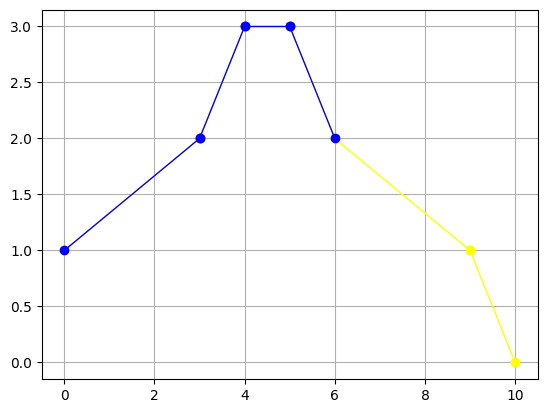

In [ ]:
# Making a graph
keylist =list(sorted_results.keys())
SC_Outflow = [None]*V


for i in range(V):
    
    veh_vars=[x for x in keylist if 'sc_commodity_outflow_'+str(i) in x and sorted_results[x] >= 0.2]
    
    SC_Outflow[i] = veh_vars

print(SC_Outflow)
for i in SC_Outflow:
    print([sorted_results[x] for x in i])
    print([x for x in i])

#max graph size  = 100x100
graphx = [None]*T
graphy = [None]*nodes
for i in range(T):
    graphx[i] = i 
for i in range(nodes):
    graphy[i] = i

colors = ['red','green','yellow','pink','blue','brown']
for count,x in enumerate(SC_Outflow):
    for y in x:

        #plot each line indiviually, basing the thickness and color of each line on the  number and type of spacecraft
        #remember to use arcs[i][j] to plot the start and end of each line
        i = int(str(y).split(",")[1])
        j = int(str(y).split(",")[2])
        t_0 = int(str(y).split(",")[-1])
        t_end = t_0 + TOF[j][i]
        wide = sorted_results[y]

        xval = [graphx[t_0],graphx[t_end]]
        yval = [graphy[i],graphy[j]]
        plt.plot(xval,yval, linewidth = wide, marker = 'o',color=colors[count] )

plt.grid(True)    
plt.show()
        



In [ ]:
# # EQUATION 7 CONSTRAINTS
#
# # Structural Fraction (fuel dependent)
# alpha = 0.045  # LOX/kerosene
#
# # Gravitational Acceleration Earth
# g_0 = 9.8  # m/s2
#
# # Upper Bound Allowed for Propellant Tank Capacity
# M_ub = 500000  # kg
#
# # Spacecraft Impulsive Burn
# t_b = 120  # s
#
#
# # Structure Mass Variable
# def create_s_star_variables(model, v=V):
#     variables = {}
#     for v in range(V):
#         variables[v] = model.addVar(vtype=GRB.CONTINUOUS, name=f'Structure_Mass_{v}')
#     return variables
#
#
# s_star = create_s_star_variables(model=m)
#
# m.update()

In [ ]:
# # CONSTRAINTS 7
#
# for v in tqdm(V):
#     m.addConstr(s_star[v] = 2.3931 * )